# EV Charging Infrastructure Visualization Dashboard

## Subject

This notebook presents the visualization and dashboard component of the **EV Charging Infrastructure and Range Anxiety Big Data project**. The analysis focuses on understanding how EV charging infrastructure is distributed across the United States, how deployment has changed over time, which charger types and networks dominate the market, and which regions may still experience charging access gaps.

## Objective

The objective of this notebook is to convert the cleaned and processed project datasets into clear, report-ready and demo-ready visual analytics. The visualizations support the project goal of identifying EV charging infrastructure patterns, geographic disparities, charger availability differences, and charging desert areas that may contribute to range anxiety.

## Scope of Analysis

This notebook includes visual analysis for:

- State-level EV charging station deployment
- City-level EV charging station deployment
- Yearly and monthly installation trends
- Charger type distribution and growth over time
- EV charging network distribution
- State-level choropleth mapping
- Station-level geographic mapping using latitude and longitude
- Charging desert and adequate coverage analysis by state
- Regional charging desert and coverage comparison
- Final dashboard-style HTML summary output

## Output Artifacts

The notebook generates reusable CSV summary tables, static PNG charts for the final report, interactive HTML charts for demo use, and a consolidated dashboard page. These outputs are saved under:

- `outputs/tables/`
- `outputs/figures/`
- `outputs/dashboard_exports/`

## Project Relevance

This visualization workflow supports the broader project by turning processed big data outputs into interpretable insights. The results help explain where EV charging infrastructure is concentrated, where gaps remain, and how charger type, network presence, and geographic coverage influence EV accessibility and range anxiety.

This cell below initializes the project folder structure and defines the required input/output paths for the EV charging analysis. These paths help ensure that cleaned datasets, figures, tables, and dashboard exports are loaded and saved consistently.

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

BASE_DIR = os.path.abspath("..") if os.getcwd().endswith("notebooks") else os.getcwd()

CLEANED_STATIONS_PATH = os.path.join(BASE_DIR, "data/processed/cleaned_stations.parquet")
STATIONS_CENSUS_PATH = os.path.join(BASE_DIR, "data/processed/stations_with_census.parquet")
COUNTY_FEATURES_PATH = os.path.join(BASE_DIR, "data/processed/county_level_features.parquet")

FIG_DIR = os.path.join(BASE_DIR, "outputs/figures")
TABLE_DIR = os.path.join(BASE_DIR, "outputs/tables")
DASHBOARD_DIR = os.path.join(BASE_DIR, "outputs/dashboard_exports")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(DASHBOARD_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Cleaned stations exists:", os.path.exists(CLEANED_STATIONS_PATH))
print("Stations + Census exists:", os.path.exists(STATIONS_CENSUS_PATH))
print("County/ZCTA features exists:", os.path.exists(COUNTY_FEATURES_PATH))

Base directory: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis
Cleaned stations exists: True
Stations + Census exists: True
County/ZCTA features exists: True


In [4]:
stations_df = pd.read_parquet(CLEANED_STATIONS_PATH)
stations_census_df = pd.read_parquet(STATIONS_CENSUS_PATH)
coverage_df = pd.read_parquet(COUNTY_FEATURES_PATH)

print("cleaned_stations shape:", stations_df.shape)
print("stations_with_census shape:", stations_census_df.shape)
print("county_level_features shape:", coverage_df.shape)

display(stations_df.head())
display(coverage_df.head())

cleaned_stations shape: (78085, 23)
stations_with_census shape: (78085, 25)
county_level_features shape: (33666, 17)


,ID,Station Name,City,State,ZIP,Latitude,Longitude,Access Code,Status Code,Open Date,...,EV Network,EV Connector Types,Country,open_date_parsed,install_year,install_month,total_ports,charger_level,is_dcfc,region
0,1523,Los Angeles Convention Center,Los Angeles,CA,90015,34.040539,-118.271387,public,E,1995-08-30,...,Non-Networked,J1772,US,1995-08-30,1995.0,8.0,8,Level2,0,West
1,6355,Scripps Green Hospital,La Jolla,CA,92037,32.899470,-117.243000,public,E,1997-07-30,...,Non-Networked,J1772,US,1997-07-30,1997.0,7.0,1,Level2,0,West
2,6405,Galpin Motors,Sepulveda,CA,91343,34.221665,-118.468371,public,E,2012-12-11,...,Non-Networked,J1772,US,2012-12-11,2012.0,12.0,2,Level2,0,West
3,6425,Galleria at Tyler,Riverside,CA,92503,33.909914,-117.459053,public,E,1997-08-30,...,Non-Networked,J1772,US,1997-08-30,1997.0,8.0,4,Level2,0,West
4,6505,City of Pasadena - Holly Street Garage,Pasadena,CA,91103,34.147620,-118.147111,public,E,2014-01-20,...,Non-Networked,J1772,US,2014-01-20,2014.0,1.0,26,Level2,0,West


,ZIP_ZCTA,total_population,median_household_income,State,region,total_stations,dcfc_stations,total_ports,total_level2_ports,total_dcfc_ports,zip_lat,zip_lon,chargers_per_10k,final_lat,final_lon,nearest_dcfc_miles,is_charging_desert
0,01001,16136,71924.0,MA,Northeast,17,4,40,30,10,42.081758,-72.625658,10.5354,42.081758,-72.625658,0.610329,0
1,01002,24726,69411.0,MA,Northeast,33,2,71,69,2,42.374764,-72.511453,13.3463,42.374764,-72.511453,0.538109,0
2,01003,12458,NaN,MA,Northeast,23,1,45,44,1,42.390631,-72.527399,18.4620,42.390631,-72.527399,0.410382,0
3,01005,4786,97390.0,MA,Northeast,1,0,2,2,0,42.423217,-72.109083,2.0894,42.423217,-72.109083,10.146929,0
4,01007,15406,99056.0,MA,Northeast,6,2,10,8,2,42.269698,-72.417327,3.8946,42.269698,-72.417327,0.131462,0


# EV chargers by state

This section builds the visualization dataset by validating that the cleaned station data contains the required columns for state-level analysis. It then aggregates EV charging infrastructure by state, calculating both the number of charging stations and total available ports.

In [5]:
required_cols = ["State", "total_ports"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required columns are present.")
print(stations_df[required_cols].head())

Required columns are present.
  State  total_ports
0    CA            8
1    CA            1
2    CA            2
3    CA            4
4    CA           26


In [6]:
state_summary = (
    stations_df
    .dropna(subset=["State"])
    .groupby("State", as_index=False)
    .agg(
        station_count=("State", "size"),
        total_ports=("total_ports", "sum")
    )
    .sort_values("station_count", ascending=False)
)

display(state_summary.head(15))

state_summary.to_csv(
    os.path.join(TABLE_DIR, "state_charger_summary.csv"),
    index=False
)

,State,station_count,total_ports
4,CA,18988,63103
34,NY,5118,18997
9,FL,4183,14199
19,MA,4139,10581
43,TX,3714,11860
47,WA,2823,7915
5,CO,2659,7174
10,GA,2300,7229
22,MI,1974,5330
38,PA,1954,5542


This cell creates a polished bar chart showing the top 15 U.S. states with the highest number of EV charging stations. The visualization highlights which states have attracted the most charging infrastructure deployments and makes the state-level distribution easier to compare.


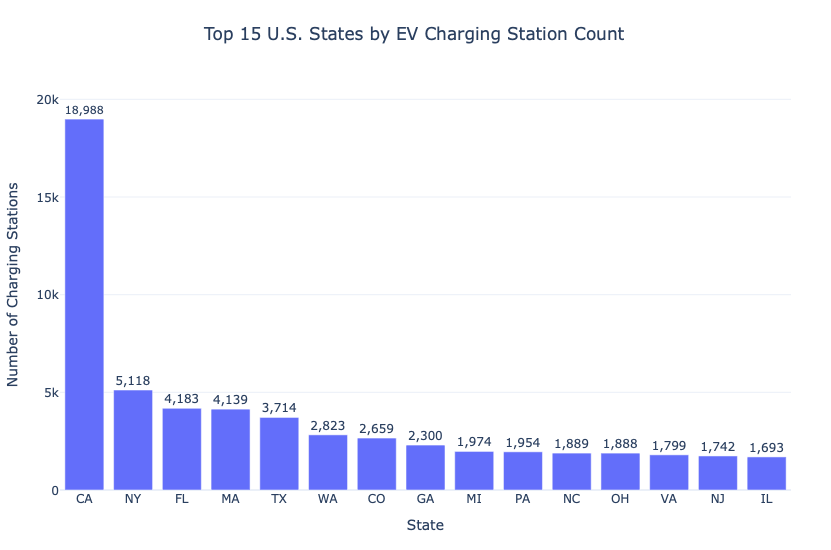

In [7]:
top_states = state_summary.head(15)

fig_state_bar = px.bar(
    top_states,
    x="State",
    y="station_count",
    text="station_count",
    title="Top 15 U.S. States by EV Charging Station Count",
    labels={
        "state": "State",
        "station_count": "Number of Charging Stations"
    }
)

fig_state_bar.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig_state_bar.update_layout(
    title_x=0.5,
    xaxis_title="State",
    yaxis_title="Number of Charging Stations",
    template="plotly_white",
    height=550,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig_state_bar.show()

In [10]:
state_bar_html = os.path.join(FIG_DIR, "top_15_states_ev_charging_stations.html")
state_bar_png = os.path.join(FIG_DIR, "top_15_states_ev_charging_stations.png")

fig_state_bar.write_html(state_bar_html)
fig_state_bar.write_image(state_bar_png, scale=2)

print("Saved HTML:", state_bar_html)
print("Saved PNG:", state_bar_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/top_15_states_ev_charging_stations.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/top_15_states_ev_charging_stations.png


### EV Charger Deployment by State

This chart shows the top 15 U.S. states by EV charging station count using the cleaned AFDC station dataset prepared during the Spark data-processing stage. The visualization highlights the geographic concentration of EV charging infrastructure and helps identify states that have attracted the largest share of charger deployments.

The result directly supports the project objective of identifying which states have the highest EV charging deployment and where charging infrastructure is concentrated. This chart also becomes a baseline for later comparison with population, income, DC fast charger availability, and charging desert status.

## EV chargers by city:

This section prepares the city-level dataset needed to analyze where EV charging stations are most concentrated across the U.S. It validates the required columns, standardizes city and state names for consistency, aggregates station and port counts by city, and saves the final summary table for visualization and reporting.


In [13]:
required_cols = ["City", "State", "total_ports"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required city-level columns are present.")
print(stations_df[required_cols].head())

Required city-level columns are present.
          City State  total_ports
0  Los Angeles    CA            8
1     La Jolla    CA            1
2    Sepulveda    CA            2
3    Riverside    CA            4
4     Pasadena    CA           26


In [18]:
city_summary = (
    stations_df
    .dropna(subset=["City", "State"])
    .assign(
        city=lambda df: df["City"].astype(str).str.strip().str.title(),
        state=lambda df: df["State"].astype(str).str.strip().str.upper()
    )
    .groupby(["City", "State"], as_index=False)
    .agg(
        station_count=("city", "size"),
        total_ports=("total_ports", "sum")
    )
    .sort_values("station_count", ascending=False)
)

city_summary["city_state"] = city_summary["City"] + ", " + city_summary["State"]

display(city_summary.head(20))

city_summary.to_csv(
    os.path.join(TABLE_DIR, "city_charger_summary.csv"),
    index=False
)

,City,State,station_count,total_ports,city_state
4414,Los Angeles,CA,1889,7839,"Los Angeles, CA"
6832,San Diego,CA,886,2960,"San Diego, CA"
3666,Irvine,CA,775,1694,"Irvine, CA"
308,Atlanta,GA,740,2345,"Atlanta, GA"
779,Boston,MA,728,1808,"Boston, MA"
350,Austin,TX,694,1731,"Austin, TX"
6998,Seattle,WA,670,1770,"Seattle, WA"
6841,San Jose,CA,651,2279,"San Jose, CA"
6836,San Francisco,CA,632,1561,"San Francisco, CA"
6749,Sacramento,CA,463,1757,"Sacramento, CA"


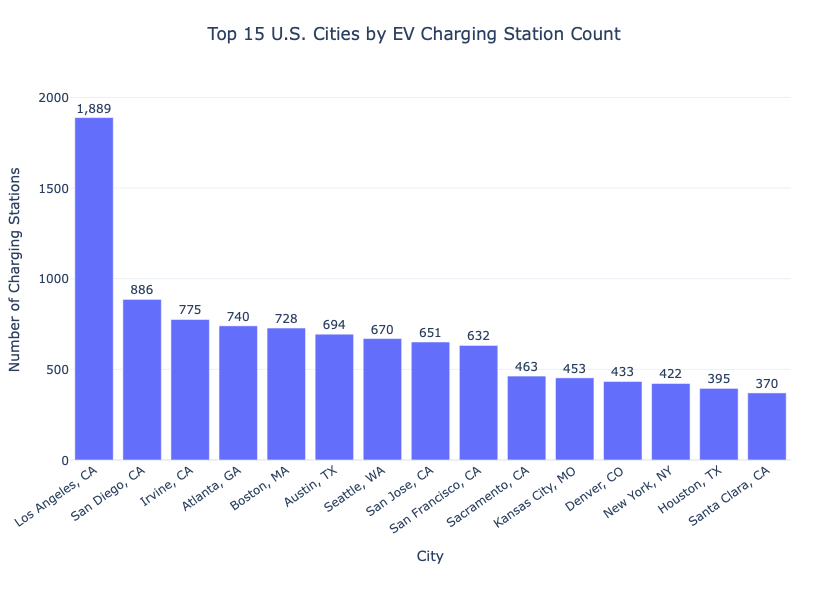

In [20]:
top_cities = city_summary.head(15)

fig_city_bar = px.bar(
    top_cities,
    x="city_state",
    y="station_count",
    text="station_count",
    title="Top 15 U.S. Cities by EV Charging Station Count",
    labels={
        "city_state": "City",
        "station_count": "Number of Charging Stations"
    },
    hover_data={
        "City": False,
        "State": True,
        "city_state": False,
        "station_count": ":,",
        "total_ports": ":,"
    }
)

fig_city_bar.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig_city_bar.update_layout(
    title_x=0.5,
    xaxis_title="City",
    yaxis_title="Number of Charging Stations",
    template="plotly_white",
    height=600,
    margin=dict(l=70, r=40, t=80, b=140),
    xaxis_tickangle=-35
)

fig_city_bar.show()

In [21]:
city_bar_html = os.path.join(FIG_DIR, "top_15_cities_ev_charging_stations.html")
city_bar_png = os.path.join(FIG_DIR, "top_15_cities_ev_charging_stations.png")

fig_city_bar.write_html(city_bar_html)
fig_city_bar.write_image(city_bar_png, scale=2)

print("Saved HTML:", city_bar_html)
print("Saved PNG:", city_bar_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/top_15_cities_ev_charging_stations.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/top_15_cities_ev_charging_stations.png


### EV Charger Deployment by City

This chart ranks the top 15 U.S. cities by EV charging station count using the cleaned AFDC station dataset. It highlights how EV charging infrastructure is concentrated around major urban, technology, tourism, and high-EV-adoption regions.

This visualization supports the project objective of identifying which destination cities have attracted the majority of EV charger deployments in the United States. It also helps connect station deployment patterns with later dashboard views such as charger type, network provider, population, income, and charging desert status.

## Yearly EV charger installation trend

This section prepares the yearly installation trend dataset using the `install_year` field from the cleaned station data. It validates that the year column is available, summarizes the distribution of installation years, aggregates station and port counts by year, and saves the yearly trend table for the final temporal analysis visualization.


In [23]:
required_cols = ["install_year"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required yearly trend column is present.")
print(stations_df[["install_year"]].head())
print(stations_df["install_year"].describe())

Required yearly trend column is present.
   install_year
0        1995.0
1        1997.0
2        2012.0
3        1997.0
4        2014.0
count    77851.000000
mean      2021.895339
std          2.938215
min       1995.000000
25%       2021.000000
50%       2022.000000
75%       2024.000000
max       2026.000000
Name: install_year, dtype: float64


In [24]:
yearly_summary = (
    stations_df
    .dropna(subset=["install_year"])
    .assign(install_year=lambda df: df["install_year"].astype(int))
    .groupby("install_year", as_index=False)
    .agg(
        station_count=("install_year", "size"),
        total_ports=("total_ports", "sum")
    )
    .sort_values("install_year")
)

display(yearly_summary)

yearly_summary.to_csv(
    os.path.join(TABLE_DIR, "yearly_installation_summary.csv"),
    index=False
)

,install_year,station_count,total_ports
0,1995,1,8
1,1997,4,11
2,1998,10,50
3,1999,1,16
4,2000,3,11
5,2001,1,4
6,2002,12,38
7,2004,14,39
8,2005,2,9
9,2006,2,6


In [25]:
yearly_summary_filtered = yearly_summary[
    (yearly_summary["install_year"] >= 2010) &
    (yearly_summary["install_year"] <= 2026)
].copy()

display(yearly_summary_filtered)

,install_year,station_count,total_ports
12,2010,33,242
13,2011,310,813
14,2012,586,1501
15,2013,360,1444
16,2014,774,2470
17,2015,1457,4344
18,2016,1501,4323
19,2017,1788,5571
20,2018,2146,8871
21,2019,2555,8888


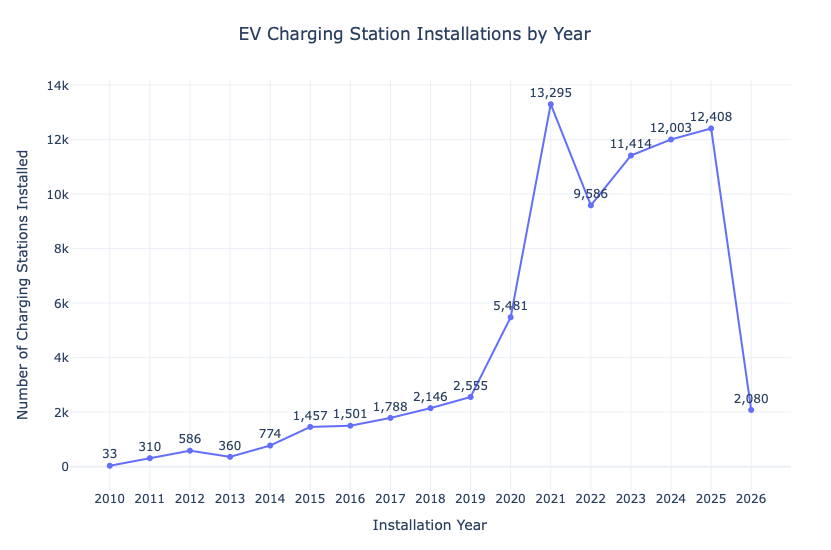

In [26]:
fig_yearly = px.line(
    yearly_summary_filtered,
    x="install_year",
    y="station_count",
    markers=True,
    title="EV Charging Station Installations by Year",
    labels={
        "install_year": "Installation Year",
        "station_count": "Number of Charging Stations Installed"
    },
    hover_data={
        "install_year": True,
        "station_count": ":,",
        "total_ports": ":,"
    }
)

fig_yearly.update_traces(
    mode="lines+markers+text",
    text=yearly_summary_filtered["station_count"],
    textposition="top center",
    texttemplate="%{text:,}"
)

fig_yearly.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=40, t=80, b=60),
    xaxis=dict(dtick=1),
    yaxis_title="Number of Charging Stations Installed"
)

fig_yearly.show()

In [27]:
yearly_html = os.path.join(FIG_DIR, "yearly_ev_charger_installation_trend.html")
yearly_png = os.path.join(FIG_DIR, "yearly_ev_charger_installation_trend.png")

fig_yearly.write_html(yearly_html)
fig_yearly.write_image(yearly_png, scale=2)

print("Saved HTML:", yearly_html)
print("Saved PNG:", yearly_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/yearly_ev_charger_installation_trend.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/yearly_ev_charger_installation_trend.png


### EV Charging Station Installations by Year

This line chart shows the yearly growth of EV charging station installations using the cleaned AFDC dataset and the processed `install_year` feature. The trend helps reveal how EV charging infrastructure has expanded over time and whether deployment accelerated in recent years.

This visualization directly supports the project objective of analyzing how EV charger installations have changed over the years. It also provides temporal context for later analysis of charger type growth, network expansion, and charging desert reduction.

# Monthly EV charger installation trend

This section prepares and visualizes monthly EV charging station installation trends. It validates the required month and port columns, aggregates station and port counts by installation month, saves the monthly summary table, and creates a polished bar chart to compare installation patterns across the year.


In [28]:
required_cols = ["install_month", "total_ports"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required monthly trend columns are present.")
print(stations_df[required_cols].head())
print(stations_df["install_month"].describe())

Required monthly trend columns are present.
   install_month  total_ports
0            8.0            8
1            7.0            1
2           12.0            2
3            8.0            4
4            1.0           26
count    77851.000000
mean         6.027810
std          3.594767
min          1.000000
25%          3.000000
50%          6.000000
75%          9.000000
max         12.000000
Name: install_month, dtype: float64


In [29]:
month_order = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_summary = (
    stations_df
    .dropna(subset=["install_month"])
    .assign(
        install_month=lambda df: df["install_month"].astype(int)
    )
    .groupby("install_month", as_index=False)
    .agg(
        station_count=("install_month", "size"),
        total_ports=("total_ports", "sum")
    )
    .sort_values("install_month")
)

monthly_summary["month_name"] = monthly_summary["install_month"].map(month_order)

display(monthly_summary)

monthly_summary.to_csv(
    os.path.join(TABLE_DIR, "monthly_installation_summary.csv"),
    index=False
)

,install_month,station_count,total_ports,month_name
0,1,12718,31228,Jan
1,2,5400,15507,Feb
2,3,5775,19009,Mar
3,4,5379,16659,Apr
4,5,5642,17129,May
5,6,8219,22650,Jun
6,7,5721,19890,Jul
7,8,5865,18812,Aug
8,9,5834,19660,Sep
9,10,6219,19911,Oct


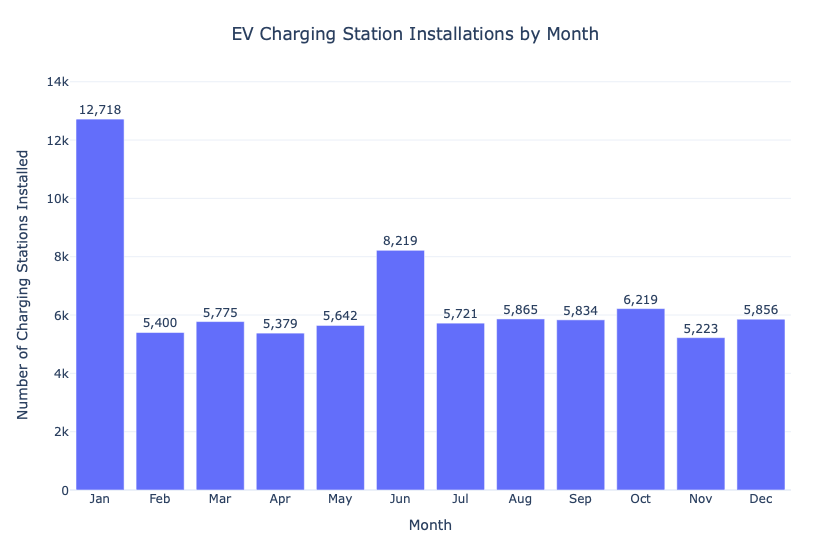

In [30]:
fig_monthly = px.bar(
    monthly_summary,
    x="month_name",
    y="station_count",
    text="station_count",
    title="EV Charging Station Installations by Month",
    labels={
        "month_name": "Installation Month",
        "station_count": "Number of Charging Stations Installed"
    },
    hover_data={
        "install_month": False,
        "month_name": False,
        "station_count": ":,",
        "total_ports": ":,"
    }
)

fig_monthly.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig_monthly.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=40, t=80, b=60),
    xaxis_title="Month",
    yaxis_title="Number of Charging Stations Installed"
)

fig_monthly.show()

In [31]:
monthly_html = os.path.join(FIG_DIR, "monthly_ev_charger_installation_trend.html")
monthly_png = os.path.join(FIG_DIR, "monthly_ev_charger_installation_trend.png")

fig_monthly.write_html(monthly_html)
fig_monthly.write_image(monthly_png, scale=2)

print("Saved HTML:", monthly_html)
print("Saved PNG:", monthly_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/monthly_ev_charger_installation_trend.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/monthly_ev_charger_installation_trend.png


### EV Charging Station Installations by Month

This bar chart shows the distribution of EV charging station installations across calendar months using the processed `install_month` feature. Unlike the yearly trend, this view focuses on seasonal or administrative deployment patterns across the dataset.

This visualization helps identify whether EV charger deployment is evenly distributed throughout the year or concentrated in specific months. It supports the project objective of analyzing monthly charger installation behavior and can be used in the final dashboard to explain temporal deployment patterns.

# Charger type distribution over years

This section prepares the charger-type trend dataset needed to compare how EV charging infrastructure has changed over time. It validates the required year, charger level, and port columns, aggregates station and port counts by installation year and charger type, filters the results to a relevant year range, and saves the summary table for the final trend visualization.


In [32]:
required_cols = ["install_year", "charger_level", "total_ports"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required charger-type trend columns are present.")
print(stations_df[required_cols].head())
print(stations_df["charger_level"].value_counts(dropna=False))

Required charger-type trend columns are present.
   install_year charger_level  total_ports
0        1995.0        Level2            8
1        1997.0        Level2            1
2        2012.0        Level2            2
3        1997.0        Level2            4
4        2014.0        Level2           26
charger_level
Level2    63508
DCFC      14488
Level1       89
Name: count, dtype: int64


In [33]:
type_year_summary = (
    stations_df
    .dropna(subset=["install_year", "charger_level"])
    .assign(
        install_year=lambda df: df["install_year"].astype(int),
        charger_level=lambda df: df["charger_level"].astype(str).str.strip()
    )
    .groupby(["install_year", "charger_level"], as_index=False)
    .agg(
        station_count=("charger_level", "size"),
        total_ports=("total_ports", "sum")
    )
)

type_year_summary = type_year_summary[
    (type_year_summary["install_year"] >= 2010) &
    (type_year_summary["install_year"] <= 2026)
].copy()

type_year_summary = type_year_summary.sort_values(["install_year", "charger_level"])

display(type_year_summary.head(30))

type_year_summary.to_csv(
    os.path.join(TABLE_DIR, "charger_type_by_year_summary.csv"),
    index=False
)

,install_year,charger_level,station_count,total_ports
14,2010,DCFC,3,44
15,2010,Level1,1,1
16,2010,Level2,29,197
17,2011,DCFC,77,207
18,2011,Level1,3,56
19,2011,Level2,230,550
20,2012,DCFC,112,290
21,2012,Level1,6,13
22,2012,Level2,468,1198
23,2013,DCFC,67,570


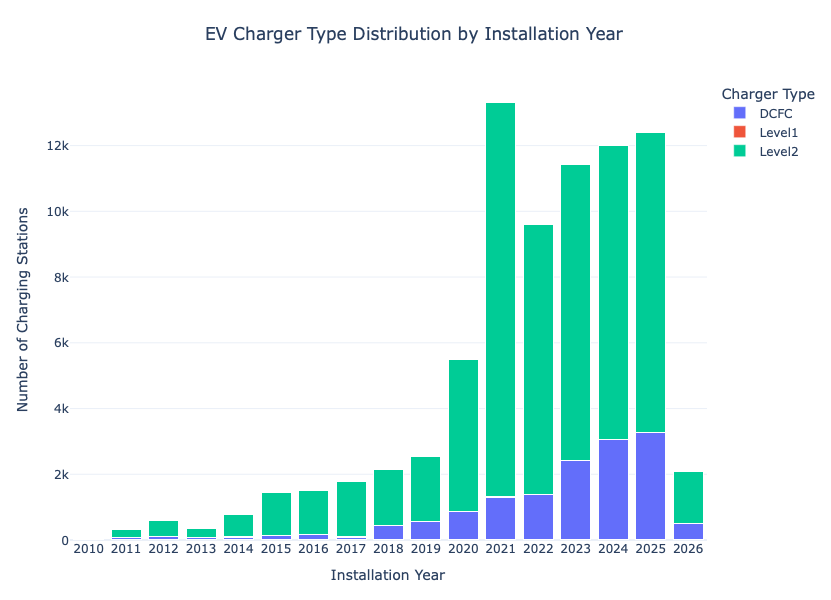

In [34]:
fig_type_year = px.bar(
    type_year_summary,
    x="install_year",
    y="station_count",
    color="charger_level",
    title="EV Charger Type Distribution by Installation Year",
    labels={
        "install_year": "Installation Year",
        "station_count": "Number of Charging Stations",
        "charger_level": "Charger Type"
    },
    hover_data={
        "install_year": True,
        "charger_level": True,
        "station_count": ":,",
        "total_ports": ":,"
    }
)

fig_type_year.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=600,
    margin=dict(l=70, r=40, t=80, b=60),
    xaxis=dict(dtick=1),
    xaxis_title="Installation Year",
    yaxis_title="Number of Charging Stations",
    legend_title_text="Charger Type",
    barmode="stack"
)

fig_type_year.show()

In [35]:
type_year_html = os.path.join(FIG_DIR, "charger_type_distribution_by_year.html")
type_year_png = os.path.join(FIG_DIR, "charger_type_distribution_by_year.png")

fig_type_year.write_html(type_year_html)
fig_type_year.write_image(type_year_png, scale=2)

print("Saved HTML:", type_year_html)
print("Saved PNG:", type_year_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/charger_type_distribution_by_year.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/charger_type_distribution_by_year.png


### Charger Type Distribution by Year

This stacked bar chart shows how EV charger deployment has changed across charger types over time. It uses the processed `install_year` and `charger_level` fields from the cleaned AFDC station dataset.

The visualization helps compare the growth of Level 2 chargers and DC fast chargers across installation years. This is important because Level 2 chargers support regular destination and workplace charging, while DC fast chargers are more relevant for long-distance travel and range-anxiety reduction.

This chart directly supports the project objective of analyzing how the distribution of charger types has changed over the years. It also provides context for charging desert analysis because counties or regions without DC fast charging access may still face range-anxiety issues even if they have slower Level 2 infrastructure.

# Charger network distribution

This checks whether the cleaned station dataset has the network-provider field needed for the chart. It also previews the most common network values so we can verify the data quality before aggregation.

In [41]:
required_cols = ["EV Network", "total_ports"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required network columns are present.")
print(stations_df[required_cols].head())
print(stations_df["EV Network"].value_counts(dropna=False).head(20))

Required network columns are present.
      EV Network  total_ports
0  Non-Networked            8
1  Non-Networked            1
2  Non-Networked            2
3  Non-Networked            4
4  Non-Networked           26
EV Network
ChargePoint Network    44349
Blink Network           5744
Non-Networked           5191
Tesla Destination       4713
Tesla                   3016
EV Connect              1416
FLO                     1178
eVgo Network            1171
Electrify America       1150
LOOP                     992
AMPUP                    836
RED_E                    805
VIALYNK                  707
SWTCH                    548
OpConnect                438
EVGATEWAY                396
FORD_CHARGE              333
NOODOE                   323
CHARGEUP                 310
UNIVERSAL                303
Name: count, dtype: int64


#### This cell groups stations by EV charging network and calculates station count plus total ports.

In [43]:
network_summary = (
    stations_df
    .assign(
        ev_network=lambda df: df["EV Network"].fillna("Unknown / Non-networked").astype(str).str.strip()
    )
    .groupby("EV Network", as_index=False)
    .agg(
        station_count=("EV Network", "size"),
        total_ports=("total_ports", "sum")
    )
    .sort_values("station_count", ascending=False)
)

display(network_summary.head(20))

network_summary.to_csv(
    os.path.join(TABLE_DIR, "network_distribution_summary.csv"),
    index=False
)

,EV Network,station_count,total_ports
15,ChargePoint Network,44349,78397
7,Blink Network,5744,21752
58,Non-Networked,5191,15131
79,Tesla Destination,4713,15647
78,Tesla,3016,36617
21,EV Connect,1416,4895
39,FLO,1178,2889
88,eVgo Network,1171,5000
34,Electrify America,1150,5619
53,LOOP,992,8024


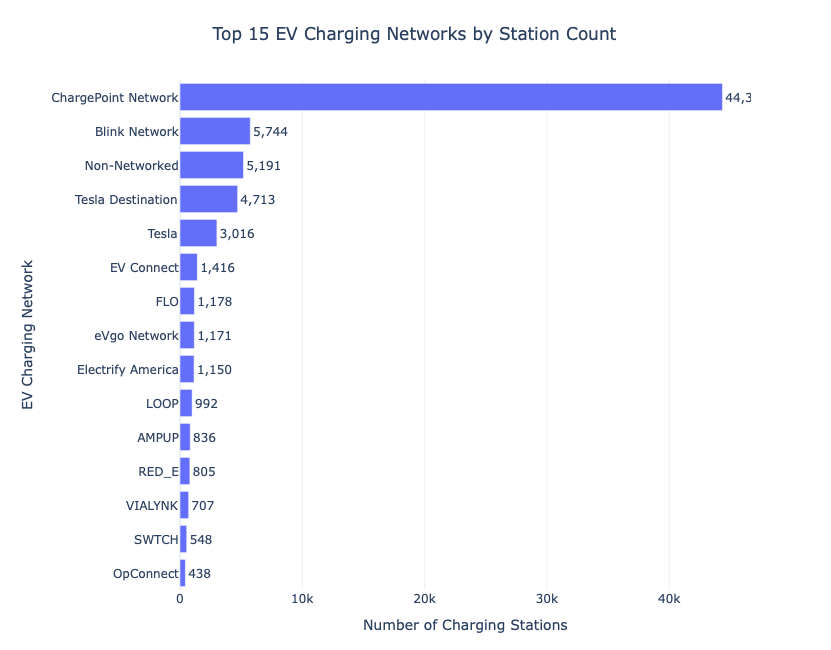

In [44]:
top_networks = network_summary.head(15)

fig_network_bar = px.bar(
    top_networks,
    x="station_count",
    y="EV Network",
    orientation="h",
    text="station_count",
    title="Top 15 EV Charging Networks by Station Count",
    labels={
        "ev_network": "EV Charging Network",
        "station_count": "Number of Charging Stations"
    },
    hover_data={
        "EV Network": True,
        "station_count": ":,",
        "total_ports": ":,"
    }
)

fig_network_bar.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig_network_bar.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=650,
    margin=dict(l=180, r=80, t=80, b=60),
    xaxis_title="Number of Charging Stations",
    yaxis_title="EV Charging Network",
    yaxis=dict(autorange="reversed")
)

fig_network_bar.show()

In [45]:
network_bar_html = os.path.join(FIG_DIR, "top_15_ev_charging_networks.html")
network_bar_png = os.path.join(FIG_DIR, "top_15_ev_charging_networks.png")

fig_network_bar.write_html(network_bar_html)
fig_network_bar.write_image(network_bar_png, scale=2)

print("Saved HTML:", network_bar_html)
print("Saved PNG:", network_bar_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/top_15_ev_charging_networks.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/top_15_ev_charging_networks.png


### EV Charging Network Distribution

This chart shows the leading EV charging networks by station count using the cleaned AFDC station dataset. It highlights the provider-side structure of the EV charging ecosystem and shows whether public charging infrastructure is concentrated among a few major operators or distributed across many smaller networks.

The visualization supports the project objective of analyzing charging infrastructure deployment patterns across the United States. Network distribution is important because charging access, pricing, connector availability, reliability, and fast-charging coverage can vary significantly by provider. This chart also provides useful context for later charging desert and DC fast-charger analysis.

# Overall charger type distribution

This visualization shows the overall split between charger categories such as Level 1, Level 2, and DC Fast Charging. It is important because charger count alone does not explain charging quality; DCFC availability is much more relevant for long-distance travel and range-anxiety reduction.

This cell below confirms that the cleaned dataset has the charger-type and port-count fields needed for the visualization. It also previews the distribution so we can catch unexpected or messy category names before plotting.

In [47]:
required_cols = ["charger_level", "total_ports"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required charger type columns are present.")
print(stations_df[required_cols].head())
print(stations_df["charger_level"].value_counts(dropna=False))

Required charger type columns are present.
  charger_level  total_ports
0        Level2            8
1        Level2            1
2        Level2            2
3        Level2            4
4        Level2           26
charger_level
Level2    63508
DCFC      14488
Level1       89
Name: count, dtype: int64


This cell below groups the cleaned station data by charger type and calculates both station count and total ports. The CSV output can be reused in the final report, dashboard, and presentation.

In [48]:
charger_type_summary = (
    stations_df
    .assign(
        charger_level=lambda df: df["charger_level"].fillna("Unknown").astype(str).str.strip()
    )
    .groupby("charger_level", as_index=False)
    .agg(
        station_count=("charger_level", "size"),
        total_ports=("total_ports", "sum")
    )
    .sort_values("station_count", ascending=False)
)

charger_type_summary["station_share_percent"] = (
    charger_type_summary["station_count"] / charger_type_summary["station_count"].sum() * 100
).round(2)

display(charger_type_summary)

charger_type_summary.to_csv(
    os.path.join(TABLE_DIR, "charger_type_distribution_summary.csv"),
    index=False
)

,charger_level,station_count,total_ports,station_share_percent
2,Level2,63508,166203,81.33
0,DCFC,14488,73955,18.55
1,Level1,89,464,0.11


This chart compares charger types using station count, which is clear and report-friendly. It helps show whether the charging network is dominated by slower Level 2 chargers or includes a meaningful share of DC fast charging infrastructure.

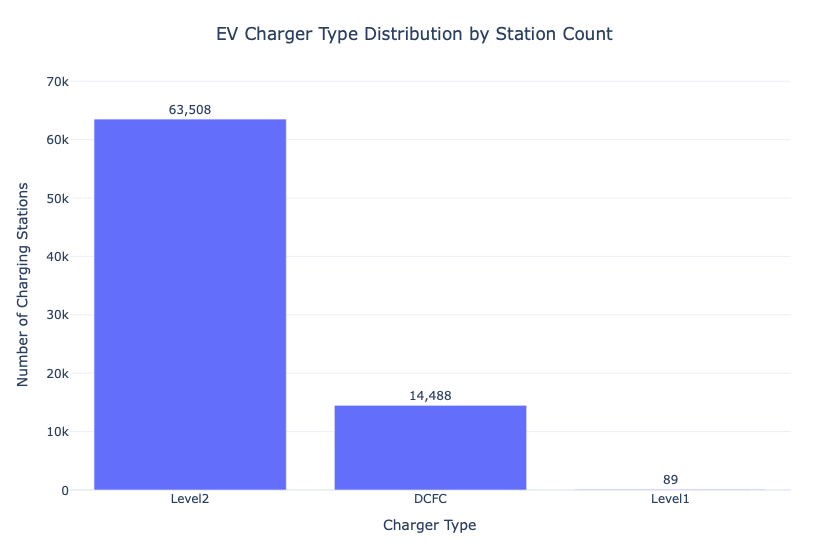

In [49]:
fig_charger_type_bar = px.bar(
    charger_type_summary,
    x="charger_level",
    y="station_count",
    text="station_count",
    title="EV Charger Type Distribution by Station Count",
    labels={
        "charger_level": "Charger Type",
        "station_count": "Number of Charging Stations"
    },
    hover_data={
        "charger_level": True,
        "station_count": ":,",
        "total_ports": ":,",
        "station_share_percent": ":.2f"
    }
)

fig_charger_type_bar.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig_charger_type_bar.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=40, t=80, b=60),
    xaxis_title="Charger Type",
    yaxis_title="Number of Charging Stations"
)

fig_charger_type_bar.show()

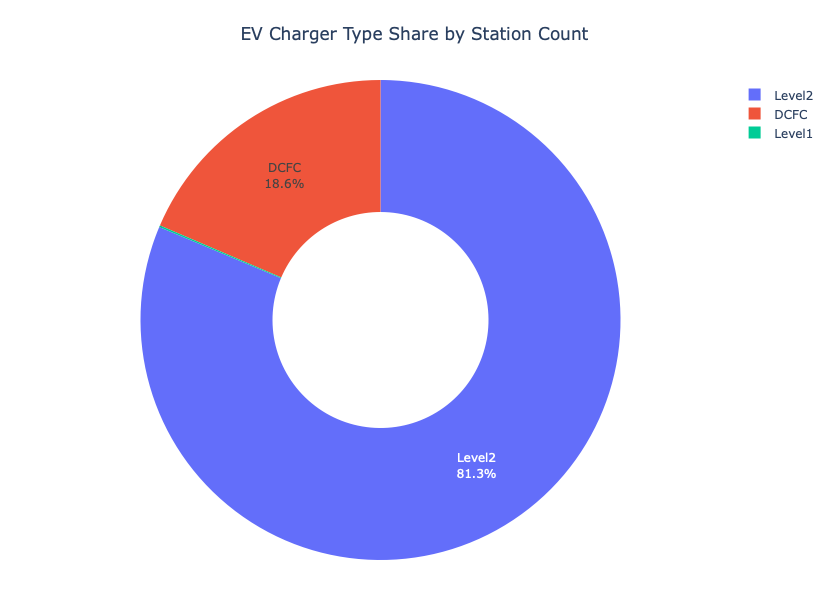

In [50]:
fig_charger_type_donut = px.pie(
    charger_type_summary,
    names="charger_level",
    values="station_count",
    hole=0.45,
    title="EV Charger Type Share by Station Count"
)

fig_charger_type_donut.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig_charger_type_donut.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=600,
    margin=dict(l=40, r=40, t=80, b=40)
)

fig_charger_type_donut.show()

In [51]:
charger_type_bar_html = os.path.join(FIG_DIR, "charger_type_distribution_bar.html")
charger_type_bar_png = os.path.join(FIG_DIR, "charger_type_distribution_bar.png")

charger_type_donut_html = os.path.join(FIG_DIR, "charger_type_distribution_donut.html")
charger_type_donut_png = os.path.join(FIG_DIR, "charger_type_distribution_donut.png")

fig_charger_type_bar.write_html(charger_type_bar_html)
fig_charger_type_bar.write_image(charger_type_bar_png, scale=2)

fig_charger_type_donut.write_html(charger_type_donut_html)
fig_charger_type_donut.write_image(charger_type_donut_png, scale=2)

print("Saved HTML:", charger_type_bar_html)
print("Saved PNG:", charger_type_bar_png)
print("Saved HTML:", charger_type_donut_html)
print("Saved PNG:", charger_type_donut_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/charger_type_distribution_bar.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/charger_type_distribution_bar.png
Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/charger_type_distribution_donut.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/charger_type_distribution_donut.png


### Overall Charger Type Distribution

This visualization shows the overall distribution of EV charging stations by charger type using the cleaned AFDC dataset. It compares the presence of Level 1, Level 2, DC Fast Charging, and any unknown charger categories in the processed station data.

The result helps explain the quality and usability of the charging infrastructure, not just the number of stations. Level 2 chargers are useful for destination, workplace, and longer-duration charging, while DC fast chargers are more important for highway travel, fast turnaround, and reducing range anxiety.

This chart supports the project’s infrastructure gap analysis because areas with many chargers may still be underserved if they lack DC fast charging access. It also provides context for the later charging desert and adequate coverage visualizations.

# State-level choropleth map for EV charging deployment

The state-level choropleth map visualizes the geographic distribution of EV charging station deployment across the United States. This map provides a spatial view of infrastructure concentration and helps identify states with comparatively high and low charging station availability.

This cell below prepares the state-level dataset required for choropleth mapping by using the previously generated state aggregation table. The resulting table contains station count and port count for each U.S. state.

In [54]:
state_map_df = state_summary.copy()

state_map_df["State"] = state_map_df["State"].astype(str).str.upper().str.strip()

display(state_map_df.head())

state_map_df.to_csv(
    os.path.join(TABLE_DIR, "state_choropleth_map_summary.csv"),
    index=False
)

,State,station_count,total_ports
4,CA,18988,63103
34,NY,5118,18997
9,FL,4183,14199
19,MA,4139,10581
43,TX,3714,11860


The choropleth map uses state abbreviations as geographic locations and station count as the color intensity. Darker states represent higher EV charging station deployment.

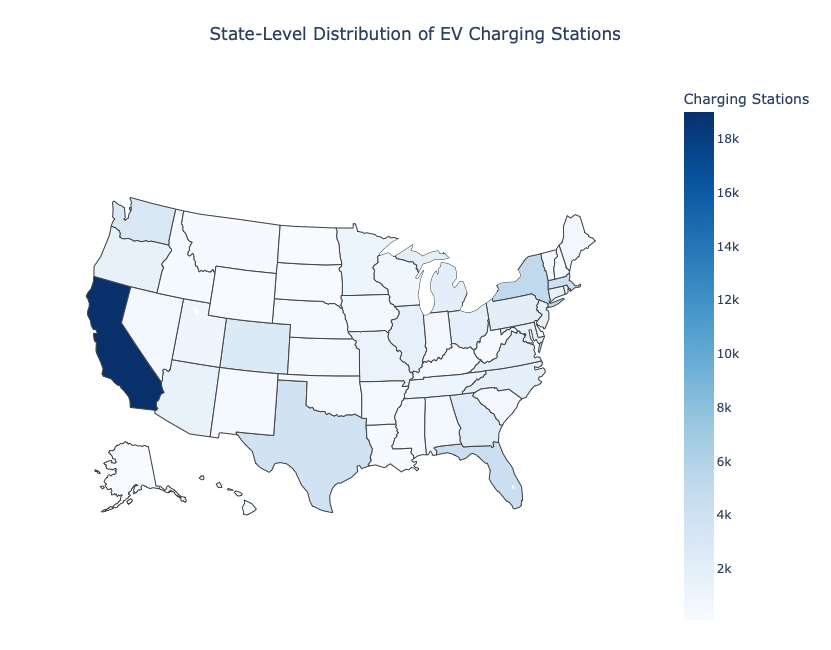

In [56]:
fig_state_choropleth = px.choropleth(
    state_map_df,
    locations="State",
    locationmode="USA-states",
    color="station_count",
    scope="usa",
    title="State-Level Distribution of EV Charging Stations",
    labels={
        "station_count": "Charging Stations",
        "state": "State"
    },
    hover_data={
        "State": True,
        "station_count": ":,",
        "total_ports": ":,"
    },
    color_continuous_scale="Blues"
)

fig_state_choropleth.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=650,
    margin=dict(l=20, r=20, t=80, b=20)
)

fig_state_choropleth.show()

In [57]:
state_map_html = os.path.join(FIG_DIR, "state_level_ev_charging_choropleth.html")
state_map_png = os.path.join(FIG_DIR, "state_level_ev_charging_choropleth.png")

fig_state_choropleth.write_html(state_map_html)
fig_state_choropleth.write_image(state_map_png, scale=2)

print("Saved HTML:", state_map_html)
print("Saved PNG:", state_map_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/state_level_ev_charging_choropleth.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/state_level_ev_charging_choropleth.png


### Interpretation: State-Level EV Charging Deployment Map

The choropleth map shows that EV charging infrastructure is not evenly distributed across the United States. States with stronger EV adoption, larger urban markets, and greater infrastructure investment show higher charging station counts, while several rural or less densely populated states show comparatively lower deployment.

This visualization supports the project objective of analyzing geographic gaps in EV charging infrastructure. It also provides a foundation for comparing raw station deployment with later coverage-based metrics such as DC fast charger availability, adequate coverage, and charging desert classification.

# Station-level interactive map using latitude and longitude

### Station-Level EV Charging Location Map

The station-level map visualizes individual EV charging station locations using latitude and longitude coordinates from the cleaned AFDC dataset. This view provides a granular spatial perspective of charging infrastructure concentration across cities, corridors, and regions.

The station-level map requires valid latitude, longitude, state, city, charger type, network, and port-count fields. Records with missing coordinates are excluded to ensure accurate geographic plotting.

In [60]:
required_cols = ["Latitude", "Longitude", "City", "State", "charger_level", "EV Network", "total_ports"]

missing_cols = [col for col in required_cols if col not in stations_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_stations.parquet: {missing_cols}")

print("Required station-level mapping columns are present.")
print(stations_df[required_cols].head())

Required station-level mapping columns are present.
    Latitude   Longitude         City State charger_level     EV Network  \
0  34.040539 -118.271387  Los Angeles    CA        Level2  Non-Networked   
1  32.899470 -117.243000     La Jolla    CA        Level2  Non-Networked   
2  34.221665 -118.468371    Sepulveda    CA        Level2  Non-Networked   
3  33.909914 -117.459053    Riverside    CA        Level2  Non-Networked   
4  34.147620 -118.147111     Pasadena    CA        Level2  Non-Networked   

   total_ports  
0            8  
1            1  
2            2  
3            4  
4           26  


A sample of station-level records is used to keep the interactive map responsive inside the notebook and browser. The full cleaned dataset remains available for analysis, while the sampled table is optimized for dashboard-style visualization.

In [64]:
station_map_df = (
    stations_df
    .dropna(subset=["Latitude", "Longitude"])
    .copy()
)

station_map_df["City"] = station_map_df["City"].fillna("Unknown").astype(str).str.title()
station_map_df["State"] = station_map_df["State"].fillna("Unknown").astype(str).str.upper()
station_map_df["charger_level"] = station_map_df["charger_level"].fillna("Unknown").astype(str)
station_map_df["EV Network"] = station_map_df["EV Network"].fillna("Unknown / Non-networked").astype(str)

station_map_df = station_map_df[
    (station_map_df["Latitude"].between(24, 50)) &
    (station_map_df["Longitude"].between(-125, -66))
].copy()

station_map_sample = station_map_df.sample(
    n=min(8000, len(station_map_df)),
    random_state=42
)

display(station_map_sample.head())
print("Station records available for mapping:", len(station_map_df))
print("Station records sampled for interactive map:", len(station_map_sample))

station_map_sample.to_csv(
    os.path.join(TABLE_DIR, "station_level_map_sample.csv"),
    index=False
)

,ID,Station Name,City,State,ZIP,Latitude,Longitude,Access Code,Status Code,Open Date,...,EV Network,EV Connector Types,Country,open_date_parsed,install_year,install_month,total_ports,charger_level,is_dcfc,region
67270,397528,Fairfield Library,Fairfield,CA,94533,38.252054,-122.048143,public,E,2025-06-02,...,EVCS,CHADEMO J1772COMBO,US,2025-06-02,2025.0,6.0,8,DCFC,1,West
25129,192721,OAP EV CHARGERS OAP #3,Dallas,TX,75201,32.791967,-96.795126,public,E,2021-07-10,...,ChargePoint Network,J1772,US,2021-07-10,2021.0,7.0,2,Level2,0,South
9499,148424,"10 G Street, NE",Washington,DC,20002,38.899837,-77.007107,public,E,2015-03-05,...,Blink Network,J1772,US,2015-03-05,2015.0,3.0,1,Level2,0,South
40951,259010,ES1 SALIDA PL1,Salida,CO,81201,38.523482,-105.983897,public,E,2023-04-12,...,ChargePoint Network,J1772COMBO TESLA,US,2023-04-12,2023.0,4.0,1,DCFC,1,West
41198,259724,Toot'n Totum - Tesla Supercharger,Plainview,TX,79072,34.188768,-101.749180,public,E,2023-04-13,...,Tesla,TESLA,US,2023-04-13,2023.0,4.0,8,DCFC,1,South


Station records available for mapping: 77636
Station records sampled for interactive map: 8000


The interactive map plots sampled EV charging stations across the United States using geographic coordinates. Each point includes city, state, charger type, network provider, and port-count information for dashboard exploration.

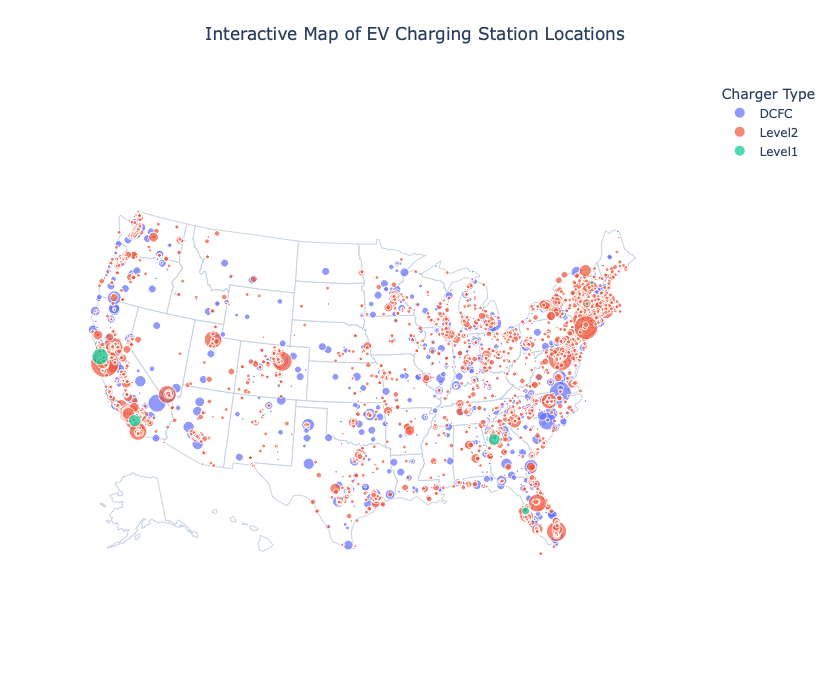

In [66]:
fig_station_map = px.scatter_geo(
    station_map_sample,
    lat="Latitude",
    lon="Longitude",
    color="charger_level",
    size="total_ports",
    scope="usa",
    title="Interactive Map of EV Charging Station Locations",
    hover_name="City",
    hover_data={
        "State": True,
        "charger_level": True,
        "EV Network": True,
        "total_ports": ":,",
        "Latitude": False,
        "Longitude": False
    },
    labels={
        "charger_level": "Charger Type",
        "total_ports": "Total Ports"
    }
)

fig_station_map.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=700,
    margin=dict(l=20, r=20, t=80, b=20),
    legend_title_text="Charger Type"
)

fig_station_map.show()

In [67]:
station_map_html = os.path.join(FIG_DIR, "station_level_ev_charging_map.html")
station_map_png = os.path.join(FIG_DIR, "station_level_ev_charging_map.png")

fig_station_map.write_html(station_map_html)
fig_station_map.write_image(station_map_png, scale=2)

print("Saved HTML:", station_map_html)
print("Saved PNG:", station_map_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/station_level_ev_charging_map.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/station_level_ev_charging_map.png


### Interpretation: Station-Level EV Charging Location Map

The station-level map shows that EV charging infrastructure is highly concentrated around urban centers, coastal regions, technology hubs, and major travel corridors. Areas with denser point clusters represent stronger charging availability, while sparse regions indicate weaker infrastructure presence.

This visualization supports the project’s geospatial analysis objective by showing charging deployment at a granular location level. It also provides context for charging desert analysis because station presence alone does not guarantee adequate fast-charging coverage across rural or long-distance travel regions.

# Charging desert and adequate coverage analysis

### Charging Desert and Adequate Coverage Analysis

Charging desert analysis identifies counties or geographic areas with insufficient EV fast-charging infrastructure. This section uses the processed county-level feature dataset to compare underserved areas with adequately covered areas across states.

The county-level feature dataset is used for coverage-based analysis rather than raw station-count analysis. This inspection step verifies the available columns before defining desert and adequate coverage categories.

In [68]:
print("County-level feature columns:")
print(list(coverage_df.columns))

print("County-level feature shape:", coverage_df.shape)

display(coverage_df.head())

County-level feature columns:
['ZIP_ZCTA', 'total_population', 'median_household_income', 'State', 'region', 'total_stations', 'dcfc_stations', 'total_ports', 'total_level2_ports', 'total_dcfc_ports', 'zip_lat', 'zip_lon', 'chargers_per_10k', 'final_lat', 'final_lon', 'nearest_dcfc_miles', 'is_charging_desert']
County-level feature shape: (33666, 17)


,ZIP_ZCTA,total_population,median_household_income,State,region,total_stations,dcfc_stations,total_ports,total_level2_ports,total_dcfc_ports,zip_lat,zip_lon,chargers_per_10k,final_lat,final_lon,nearest_dcfc_miles,is_charging_desert
0,01001,16136,71924.0,MA,Northeast,17,4,40,30,10,42.081758,-72.625658,10.5354,42.081758,-72.625658,0.610329,0
1,01002,24726,69411.0,MA,Northeast,33,2,71,69,2,42.374764,-72.511453,13.3463,42.374764,-72.511453,0.538109,0
2,01003,12458,NaN,MA,Northeast,23,1,45,44,1,42.390631,-72.527399,18.4620,42.390631,-72.527399,0.410382,0
3,01005,4786,97390.0,MA,Northeast,1,0,2,2,0,42.423217,-72.109083,2.0894,42.423217,-72.109083,10.146929,0
4,01007,15406,99056.0,MA,Northeast,6,2,10,8,2,42.269698,-72.417327,3.8946,42.269698,-72.417327,0.131462,0


This cell creates a consistent coverage_status field for visualization. Areas with no DC fast-charging availability are labeled as charging deserts, while areas with DCFC access are labeled as adequate coverage.

In [70]:
coverage_analysis_df = coverage_df.copy()

if "coverage_status" in coverage_analysis_df.columns:
    coverage_analysis_df["coverage_status"] = coverage_analysis_df["coverage_status"].astype(str)

elif "charging_desert" in coverage_analysis_df.columns:
    coverage_analysis_df["coverage_status"] = coverage_analysis_df["charging_desert"].apply(
        lambda x: "Charging Desert" if bool(x) else "Adequate Coverage"
    )

elif "is_charging_desert" in coverage_analysis_df.columns:
    coverage_analysis_df["coverage_status"] = coverage_analysis_df["is_charging_desert"].apply(
        lambda x: "Charging Desert" if bool(x) else "Adequate Coverage"
    )

elif existing_dcfc_cols:
    dcfc_col = existing_dcfc_cols[0]
    coverage_analysis_df["coverage_status"] = coverage_analysis_df[dcfc_col].fillna(0).apply(
        lambda x: "Charging Desert" if x == 0 else "Adequate Coverage"
    )
    print("Created coverage_status using:", dcfc_col)

else:
    raise ValueError(
        "No charging desert label or DCFC-related column found. Please inspect coverage_df columns and confirm the correct field."
    )

print(coverage_analysis_df["coverage_status"].value_counts(dropna=False))

display(coverage_analysis_df.head())

coverage_status
Adequate Coverage    33046
Charging Desert        620
Name: count, dtype: int64


,ZIP_ZCTA,total_population,median_household_income,State,region,total_stations,dcfc_stations,total_ports,total_level2_ports,total_dcfc_ports,zip_lat,zip_lon,chargers_per_10k,final_lat,final_lon,nearest_dcfc_miles,is_charging_desert,coverage_status
0,01001,16136,71924.0,MA,Northeast,17,4,40,30,10,42.081758,-72.625658,10.5354,42.081758,-72.625658,0.610329,0,Adequate Coverage
1,01002,24726,69411.0,MA,Northeast,33,2,71,69,2,42.374764,-72.511453,13.3463,42.374764,-72.511453,0.538109,0,Adequate Coverage
2,01003,12458,NaN,MA,Northeast,23,1,45,44,1,42.390631,-72.527399,18.4620,42.390631,-72.527399,0.410382,0,Adequate Coverage
3,01005,4786,97390.0,MA,Northeast,1,0,2,2,0,42.423217,-72.109083,2.0894,42.423217,-72.109083,10.146929,0,Adequate Coverage
4,01007,15406,99056.0,MA,Northeast,6,2,10,8,2,42.269698,-72.417327,3.8946,42.269698,-72.417327,0.131462,0,Adequate Coverage


State-level coverage comparison requires a state identifier in the county-level feature dataset. This cell standardizes the state field for grouping and visualization.

In [71]:
possible_state_cols = ["state", "State", "state_code", "STATE", "stusps"]

existing_state_cols = [col for col in possible_state_cols if col in coverage_analysis_df.columns]

if not existing_state_cols:
    raise ValueError("No state column found in county_level_features.parquet. Please inspect coverage_df columns.")

state_col = existing_state_cols[0]

coverage_analysis_df["state_standardized"] = (
    coverage_analysis_df[state_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

print("Using state column:", state_col)
display(coverage_analysis_df[["state_standardized", "coverage_status"]].head())

Using state column: State


,state_standardized,coverage_status
0,MA,Adequate Coverage
1,MA,Adequate Coverage
2,MA,Adequate Coverage
3,MA,Adequate Coverage
4,MA,Adequate Coverage


This cell summarizes charging desert and adequate coverage counts by state. The resulting CSV provides a report-ready table for explaining underserved and well-covered regions.

In [72]:
state_coverage_summary = (
    coverage_analysis_df
    .dropna(subset=["state_standardized", "coverage_status"])
    .groupby(["state_standardized", "coverage_status"], as_index=False)
    .size()
    .rename(columns={"size": "area_count"})
)

state_coverage_pivot = (
    state_coverage_summary
    .pivot(index="state_standardized", columns="coverage_status", values="area_count")
    .fillna(0)
    .reset_index()
)

if "Charging Desert" not in state_coverage_pivot.columns:
    state_coverage_pivot["Charging Desert"] = 0

if "Adequate Coverage" not in state_coverage_pivot.columns:
    state_coverage_pivot["Adequate Coverage"] = 0

state_coverage_pivot["total_areas"] = (
    state_coverage_pivot["Charging Desert"] + state_coverage_pivot["Adequate Coverage"]
)

state_coverage_pivot["desert_share_percent"] = (
    state_coverage_pivot["Charging Desert"] / state_coverage_pivot["total_areas"] * 100
).round(2)

state_coverage_pivot = state_coverage_pivot.sort_values(
    "desert_share_percent",
    ascending=False
)

display(state_coverage_pivot.head(15))

state_coverage_pivot.to_csv(
    os.path.join(TABLE_DIR, "state_charging_desert_coverage_summary.csv"),
    index=False
)

coverage_status,state_standardized,Adequate Coverage,Charging Desert,total_areas,desert_share_percent
0,AK,68.0,177.0,245.0,72.24
26,MT,260.0,108.0,368.0,29.35
28,ND,304.0,84.0,388.0,21.65
11,HI,81.0,16.0,97.0,16.49
50,WY,165.0,13.0,178.0,7.30
41,SD,350.0,25.0,375.0,6.67
33,NV,172.0,10.0,182.0,5.49
16,KS,667.0,35.0,702.0,4.99
29,NE,557.0,29.0,586.0,4.95
13,ID,273.0,11.0,284.0,3.87


This chart ranks states by the percentage of areas classified as charging deserts. It shifts the analysis from raw charger deployment to infrastructure adequacy.

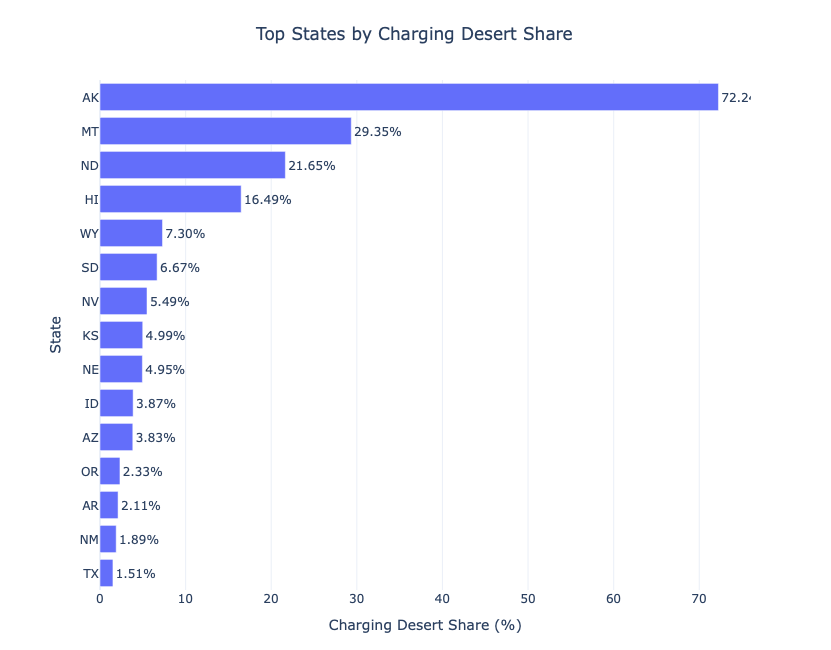

In [73]:
top_desert_states = state_coverage_pivot.head(15)

fig_state_desert_bar = px.bar(
    top_desert_states,
    x="desert_share_percent",
    y="state_standardized",
    orientation="h",
    text="desert_share_percent",
    title="Top States by Charging Desert Share",
    labels={
        "state_standardized": "State",
        "desert_share_percent": "Charging Desert Share (%)"
    },
    hover_data={
        "Charging Desert": ":,",
        "Adequate Coverage": ":,",
        "total_areas": ":,",
        "desert_share_percent": ":.2f"
    }
)

fig_state_desert_bar.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig_state_desert_bar.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=650,
    margin=dict(l=100, r=80, t=80, b=60),
    xaxis_title="Charging Desert Share (%)",
    yaxis_title="State",
    yaxis=dict(autorange="reversed")
)

fig_state_desert_bar.show()

In [74]:
state_desert_html = os.path.join(FIG_DIR, "state_charging_desert_share.html")
state_desert_png = os.path.join(FIG_DIR, "state_charging_desert_share.png")

fig_state_desert_bar.write_html(state_desert_html)
fig_state_desert_bar.write_image(state_desert_png, scale=2)

print("Saved HTML:", state_desert_html)
print("Saved PNG:", state_desert_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/state_charging_desert_share.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/state_charging_desert_share.png


### Interpretation: Charging Desert Share by State

The charging desert analysis shows which states have the highest share of geographic areas with insufficient DC fast-charging access. This provides a stronger equity and range-anxiety perspective than raw station-count analysis because a state may have many chargers overall but still contain underserved counties or regions.

This visualization supports the project objective of identifying charging deserts and high-need areas for infrastructure prioritization. It also connects directly to the policy goal of using data-driven analysis to guide NEVI funding, utility planning, and equitable EV infrastructure investment.

# Region-level charging desert and adequate coverage visuals


The region-level coverage analysis compares charging desert and adequate coverage patterns across broader U.S. regions. This view helps summarize infrastructure inequality at a higher geographic level and supports policy-oriented interpretation for regional investment planning.

This cell checks whether a region column already exists in the county-level feature dataset. If the dataset does not contain a region field, regions are assigned using standardized U.S. state groupings.

In [75]:
state_to_region = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast",
    "PA": "Northeast",

    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest",
    "WI": "Midwest", "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
    "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",

    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South",
    "NC": "South", "SC": "South", "VA": "South", "DC": "South",
    "WV": "South", "AL": "South", "KY": "South", "MS": "South",
    "TN": "South", "AR": "South", "LA": "South", "OK": "South",
    "TX": "South",

    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West",
    "NV": "West", "NM": "West", "UT": "West", "WY": "West",
    "AK": "West", "CA": "West", "HI": "West", "OR": "West",
    "WA": "West"
}

region_analysis_df = coverage_analysis_df.copy()

possible_region_cols = ["region", "Region", "census_region", "Census Region"]

existing_region_cols = [col for col in possible_region_cols if col in region_analysis_df.columns]

if existing_region_cols:
    region_col = existing_region_cols[0]
    region_analysis_df["region_standardized"] = (
        region_analysis_df[region_col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.title()
    )
    print("Using existing region column:", region_col)
else:
    region_analysis_df["region_standardized"] = (
        region_analysis_df["state_standardized"]
        .map(state_to_region)
        .fillna("Unknown")
    )
    print("Created region_standardized from state_standardized.")

print(region_analysis_df["region_standardized"].value_counts(dropna=False))

display(region_analysis_df[["state_standardized", "region_standardized", "coverage_status"]].head())

Using existing region column: region
region_standardized
South        11600
Midwest      10153
Northeast     6106
West          5807
Name: count, dtype: int64


,state_standardized,region_standardized,coverage_status
0,MA,Northeast,Adequate Coverage
1,MA,Northeast,Adequate Coverage
2,MA,Northeast,Adequate Coverage
3,MA,Northeast,Adequate Coverage
4,MA,Northeast,Adequate Coverage


This cell aggregates charging desert and adequate coverage counts by region. The output table provides a concise regional comparison for the final report and dashboard.

In [76]:
region_coverage_summary = (
    region_analysis_df
    .dropna(subset=["region_standardized", "coverage_status"])
    .groupby(["region_standardized", "coverage_status"], as_index=False)
    .size()
    .rename(columns={"size": "area_count"})
)

region_coverage_pivot = (
    region_coverage_summary
    .pivot(index="region_standardized", columns="coverage_status", values="area_count")
    .fillna(0)
    .reset_index()
)

if "Charging Desert" not in region_coverage_pivot.columns:
    region_coverage_pivot["Charging Desert"] = 0

if "Adequate Coverage" not in region_coverage_pivot.columns:
    region_coverage_pivot["Adequate Coverage"] = 0

region_coverage_pivot["total_areas"] = (
    region_coverage_pivot["Charging Desert"] + region_coverage_pivot["Adequate Coverage"]
)

region_coverage_pivot["desert_share_percent"] = (
    region_coverage_pivot["Charging Desert"] / region_coverage_pivot["total_areas"] * 100
).round(2)

region_coverage_pivot = region_coverage_pivot.sort_values(
    "desert_share_percent",
    ascending=False
)

display(region_coverage_pivot)

region_coverage_pivot.to_csv(
    os.path.join(TABLE_DIR, "region_charging_desert_coverage_summary.csv"),
    index=False
)

coverage_status,region_standardized,Adequate Coverage,Charging Desert,total_areas,desert_share_percent
3,West,5431,376,5807,6.47
0,Midwest,9972,181,10153,1.78
2,South,11543,57,11600,0.49
1,Northeast,6100,6,6106,0.10


This chart compares charging desert and adequate coverage counts across U.S. regions. It shows whether underserved infrastructure patterns are concentrated in specific regional areas.

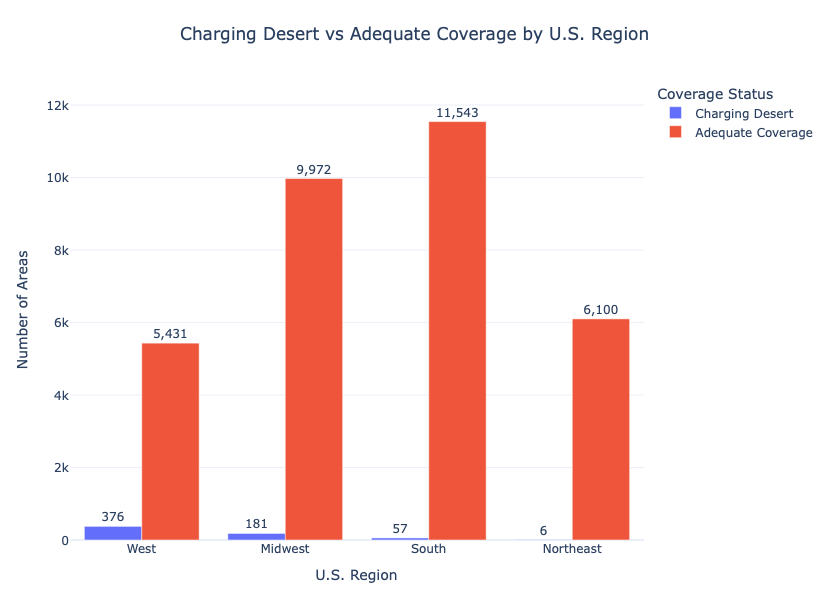

In [77]:
region_coverage_long = region_coverage_pivot.melt(
    id_vars=["region_standardized", "total_areas", "desert_share_percent"],
    value_vars=["Charging Desert", "Adequate Coverage"],
    var_name="coverage_status",
    value_name="area_count"
)

fig_region_coverage = px.bar(
    region_coverage_long,
    x="region_standardized",
    y="area_count",
    color="coverage_status",
    barmode="group",
    text="area_count",
    title="Charging Desert vs Adequate Coverage by U.S. Region",
    labels={
        "region_standardized": "U.S. Region",
        "area_count": "Number of Areas",
        "coverage_status": "Coverage Status"
    },
    hover_data={
        "region_standardized": True,
        "coverage_status": True,
        "area_count": ":,",
        "desert_share_percent": ":.2f"
    }
)

fig_region_coverage.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig_region_coverage.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=600,
    margin=dict(l=70, r=40, t=80, b=60),
    xaxis_title="U.S. Region",
    yaxis_title="Number of Areas",
    legend_title_text="Coverage Status"
)

fig_region_coverage.show()

This chart ranks U.S. regions by the percentage of areas classified as charging deserts. It provides a normalized comparison that is easier to interpret than raw counts alone.

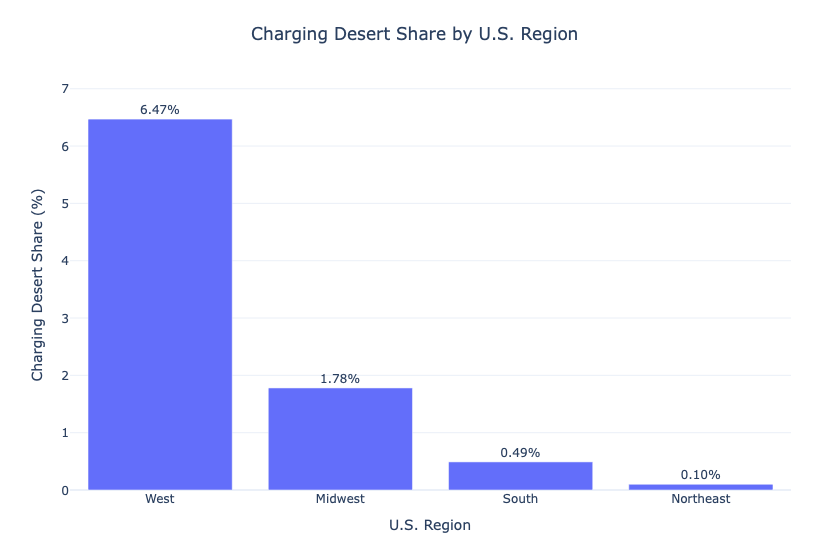

In [78]:
fig_region_desert_share = px.bar(
    region_coverage_pivot,
    x="region_standardized",
    y="desert_share_percent",
    text="desert_share_percent",
    title="Charging Desert Share by U.S. Region",
    labels={
        "region_standardized": "U.S. Region",
        "desert_share_percent": "Charging Desert Share (%)"
    },
    hover_data={
        "Charging Desert": ":,",
        "Adequate Coverage": ":,",
        "total_areas": ":,",
        "desert_share_percent": ":.2f"
    }
)

fig_region_desert_share.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig_region_desert_share.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=40, t=80, b=60),
    xaxis_title="U.S. Region",
    yaxis_title="Charging Desert Share (%)"
)

fig_region_desert_share.show()

In [79]:
region_coverage_html = os.path.join(FIG_DIR, "region_charging_desert_vs_adequate_coverage.html")
region_coverage_png = os.path.join(FIG_DIR, "region_charging_desert_vs_adequate_coverage.png")

region_desert_share_html = os.path.join(FIG_DIR, "region_charging_desert_share.html")
region_desert_share_png = os.path.join(FIG_DIR, "region_charging_desert_share.png")

fig_region_coverage.write_html(region_coverage_html)
fig_region_coverage.write_image(region_coverage_png, scale=2)

fig_region_desert_share.write_html(region_desert_share_html)
fig_region_desert_share.write_image(region_desert_share_png, scale=2)

print("Saved HTML:", region_coverage_html)
print("Saved PNG:", region_coverage_png)
print("Saved HTML:", region_desert_share_html)
print("Saved PNG:", region_desert_share_png)

Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/region_charging_desert_vs_adequate_coverage.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/region_charging_desert_vs_adequate_coverage.png
Saved HTML: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/region_charging_desert_share.html
Saved PNG: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/figures/region_charging_desert_share.png


### Interpretation: Region-Level Charging Coverage

The region-level analysis shows how charging desert and adequate coverage patterns vary across broader U.S. geographic regions. This summary helps move the analysis beyond individual states and provides a higher-level view of regional infrastructure inequality.

The visualization supports the project objective of identifying high-need areas for EV charging investment. Regions with higher charging desert shares may require stronger policy support, targeted NEVI funding, utility coordination, and fast-charging deployment along underserved corridors.

# EV Charging Visualization Dashboard

The final dashboard page combines the major visualization outputs into one structured HTML summary. This dashboard provides a presentation-ready view of state deployment, city deployment, temporal trends, charger-type patterns, network distribution, maps, and charging desert analysis.

In [88]:
import os
import base64
import html
from pathlib import Path

dashboard_html_path = os.path.join(DASHBOARD_DIR, "ev_charging_visual_dashboard.html")

team_members = [
    "Krish Jani	kj2743", "Vandana Rawat	vr2645", "Riddhi Raina Prasad rrp4822"
]


def html_to_base64_data_uri(html_path):
    """
    Converts an interactive HTML chart into a base64 data URI so it can be
    embedded directly inside the dashboard iframe.
    """
    html_path = os.path.abspath(html_path)

    if not os.path.exists(html_path):
        raise FileNotFoundError(f"Interactive HTML not found: {html_path}")

    if os.path.getsize(html_path) == 0:
        raise ValueError(f"Interactive HTML file is empty: {html_path}")

    with open(html_path, "r", encoding="utf-8") as f:
        html_content = f.read()

    encoded_html = base64.b64encode(html_content.encode("utf-8")).decode("utf-8")
    return f"data:text/html;base64,{encoded_html}"


team_members_html = "".join(
    f"<li>{html.escape(member)}</li>" for member in team_members
)

dashboard_cards = ""

for asset in dashboard_assets:
    html_full_path = os.path.abspath(os.path.join(FIG_DIR, asset["html"]))

    interactive_data_uri = html_to_base64_data_uri(html_full_path)

    dashboard_cards += f"""
    <section class="card">
        <h2>{html.escape(asset["title"])}</h2>
        <p>{html.escape(asset["description"])}</p>

        <iframe
            class="interactive-frame"
            src="{interactive_data_uri}"
            title="{html.escape(asset["title"])} Interactive Chart">
        </iframe>
    </section>
    """


dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>EV Charging Infrastructure Visualization Dashboard</title>

    <style>
        body {{
            margin: 0;
            font-family: Arial, Helvetica, sans-serif;
            background: #f5f7fb;
            color: #1f2937;
        }}

        header {{
            background: #111827;
            color: white;
            padding: 36px 48px;
        }}

        header h1 {{
            margin: 0;
            font-size: 34px;
            letter-spacing: 0.2px;
        }}

        header p {{
            margin-top: 12px;
            font-size: 16px;
            line-height: 1.6;
            max-width: 1050px;
            color: #d1d5db;
        }}

        .summary {{
            display: grid;
            grid-template-columns: 1.4fr 1fr 1fr 1fr;
            gap: 18px;
            padding: 28px 48px 8px 48px;
        }}

        .metric,
        .team-card {{
            background: white;
            border-radius: 14px;
            padding: 20px;
            box-shadow: 0 6px 18px rgba(15, 23, 42, 0.08);
        }}

        .metric h3,
        .team-card h3 {{
            margin: 0;
            font-size: 14px;
            color: #6b7280;
            text-transform: uppercase;
            letter-spacing: 0.5px;
        }}

        .metric p {{
            margin: 10px 0 0 0;
            font-size: 24px;
            font-weight: 700;
            color: #111827;
        }}

        .team-card ul {{
            margin: 12px 0 0 0;
            padding-left: 20px;
            color: #111827;
            font-size: 17px;
            font-weight: 600;
            line-height: 1.7;
        }}

        .container {{
            padding: 24px 48px 48px 48px;
        }}

        .card {{
            background: white;
            border-radius: 16px;
            padding: 26px;
            margin-bottom: 34px;
            box-shadow: 0 8px 24px rgba(15, 23, 42, 0.08);
        }}

        .card h2 {{
            margin-top: 0;
            color: #111827;
            font-size: 24px;
        }}

        .card p {{
            color: #4b5563;
            line-height: 1.6;
            font-size: 15px;
        }}

        .interactive-frame {{
            width: 100%;
            height: 720px;
            border: 1px solid #e5e7eb;
            border-radius: 12px;
            background: white;
            margin-top: 14px;
        }}

        footer {{
            padding: 24px 48px;
            background: #111827;
            color: #d1d5db;
            font-size: 14px;
            line-height: 1.6;
        }}

        @media (max-width: 900px) {{
            .summary {{
                grid-template-columns: 1fr;
                padding: 24px;
            }}

            .container {{
                padding: 24px;
            }}

            header {{
                padding: 32px 24px;
            }}

            footer {{
                padding: 24px;
            }}

            .interactive-frame {{
                height: 560px;
            }}
        }}
    </style>
</head>

<body>
    <header>
        <h1>EV Charging Infrastructure Visualization Dashboard</h1>
        <p>
            This dashboard presents the visual analytics component of the EV Charging Infrastructure
            and Range Anxiety Big Data project. It uses processed AFDC charging station data and
            county-level coverage features to analyze deployment concentration, temporal growth,
            charger-type distribution, network presence, geographic patterns, and charging desert coverage.
        </p>
    </header>

    <section class="summary">
        <div class="team-card">
            <h3>Team Members</h3>
            <ul>
                {team_members_html}
            </ul>
        </div>

        <div class="metric">
            <h3>Subject</h3>
            <p>Big Data</p>
        </div>

        <div class="metric">
            <h3>Semester</h3>
            <p>Spring Semester</p>
        </div>

        <div class="metric">
            <h3>Section</h3>
            <p>Section C</p>
        </div>
    </section>

    <main class="container">
        {dashboard_cards}
    </main>

    <footer>
        Prepared by the three-member project team for the EV Charging Infrastructure &amp; Range Anxiety
        Big Data Gap Analysis project, Spring Semester, Section C.
    </footer>
</body>
</html>
"""

with open(dashboard_html_path, "w", encoding="utf-8") as f:
    f.write(dashboard_html)

print("Dashboard created:", dashboard_html_path)
print(Path(os.path.abspath(dashboard_html_path)).as_uri())

Dashboard created: /Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/dashboard_exports/ev_charging_visual_dashboard.html
file:///Users/vandanarawat/ev_analysis_vandana/ev-charging-analysis/outputs/dashboard_exports/ev_charging_visual_dashboard.html


### Final Interactive Visualization Dashboard

The final dashboard consolidates the main interactive visual analytics outputs for the EV charging infrastructure project. It presents deployment rankings, temporal growth trends, charger-type patterns, network distribution, geospatial maps, and charging desert analysis in one organized interface.

This dashboard supports the project’s storytelling requirement by connecting raw EV charging infrastructure deployment with geographic equity and range-anxiety concerns. Since the charts are embedded as interactive visualizations, users can hover, zoom, pan, and inspect values directly within the dashboard instead of viewing only static chart images.

The dashboard also provides a demo-ready artifact for the final presentation, allowing the team to explain the visualization section clearly through a single integrated interface.